In [4]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Save model
import joblib

In [5]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

Shape: (418, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   418.000000  418.000000  418.000000  332.000000  418.000000   
mean   1100.500000    0.363636    2.265550   30.272590    0.447368   
std     120.810458    0.481

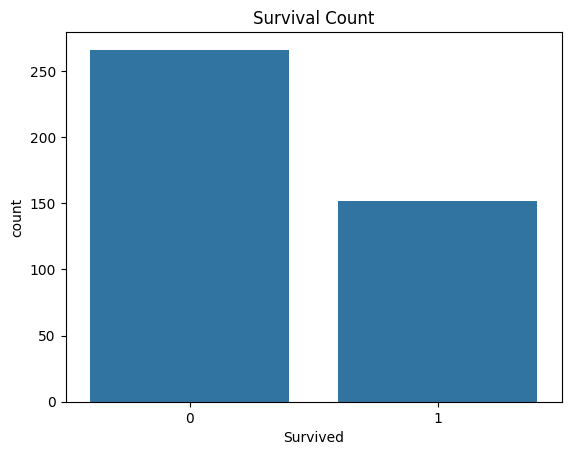

In [7]:
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")

plt.show()

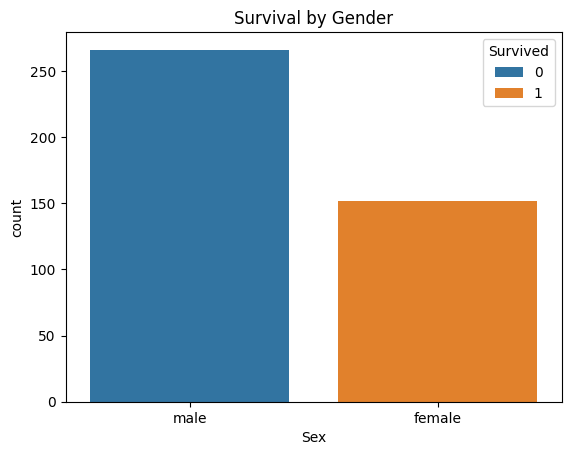

In [8]:
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")

plt.show()

In [9]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df['Title'].value_counts()


,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [11]:
df['HasCabin'] = df['Cabin'].notnull().astype(int)

In [12]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [13]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [14]:
df.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1,
    inplace=True
)

In [15]:
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['Sex', 'Embarked', 'Title'], dtype='object')


In [16]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
print(df.isnull().sum)

<bound method DataFrame.sum of      Survived  Pclass    Age  SibSp  Parch   Fare  FamilySize  HasCabin  \
0       False   False  False  False  False  False       False     False   
1       False   False  False  False  False  False       False     False   
2       False   False  False  False  False  False       False     False   
3       False   False  False  False  False  False       False     False   
4       False   False  False  False  False  False       False     False   
..        ...     ...    ...    ...    ...    ...         ...       ...   
413     False   False  False  False  False  False       False     False   
414     False   False  False  False  False  False       False     False   
415     False   False  False  False  False  False       False     False   
416     False   False  False  False  False  False       False     False   
417     False   False  False  False  False  False       False     False   

     Sex_male  Embarked_Q  Embarked_S  Title_Dona  Title_Dr  Title_M

In [22]:
df=df.fillna(0)

In [23]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [26]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [27]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [28]:
def evaluate_model(name, y_test, predictions):

    print(f"\n{name} Results")
    print("-" * 30)

    print("Accuracy:", accuracy_score(y_test, predictions))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

In [29]:
evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("Decision Tree", y_test, dt_pred)


Logistic Regression Results
------------------------------
Accuracy: 1.0

Confusion Matrix:
[[50  0]
 [ 0 34]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


Random Forest Results
------------------------------
Accuracy: 1.0

Confusion Matrix:
[[50  0]
 [ 0 34]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


Decision Tree Results
------------------------------
Accuracy: 1.0

Confusion M

In [30]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

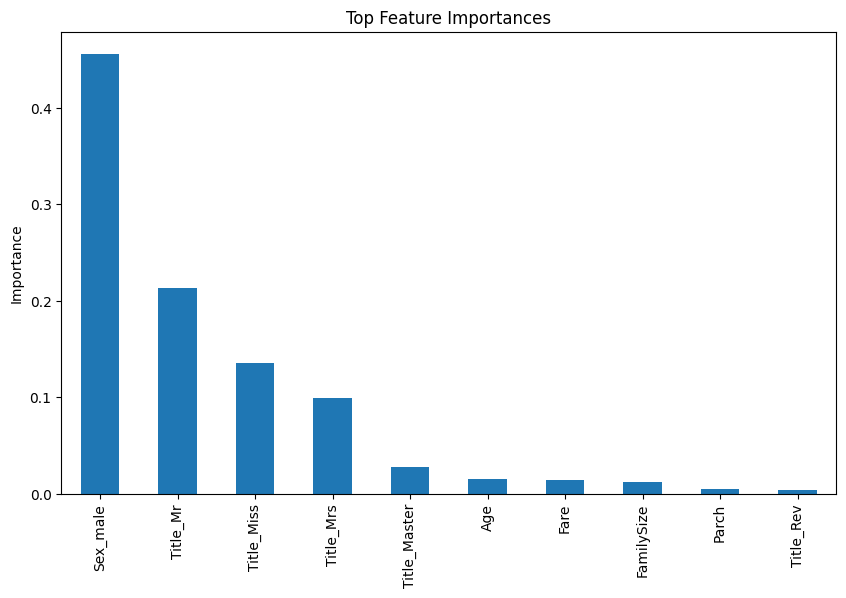

In [31]:
plt.figure(figsize=(10,6))

importance.head(10).plot(kind='bar')

plt.title("Top Feature Importances")

plt.ylabel("Importance")

plt.show()

In [32]:
joblib.dump(rf, 'best_titanic_model.pkl')

['best_titanic_model.pkl']

In [33]:
sample_passenger = pd.DataFrame(
    [X.iloc[0]],
    columns=X.columns
)

prediction = rf.predict(sample_passenger)

print("Survival Prediction:", prediction[0])

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Survival Prediction: 0
Passenger Did Not Survive
